<a href="https://colab.research.google.com/github/eslavthsandeep/Twitter-Sentiment-Analysis/blob/main/Twitter_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle

In [2]:
!pip uninstall -y kaggle


Found existing installation: kaggle 2.0.0
Uninstalling kaggle-2.0.0:
  Successfully uninstalled kaggle-2.0.0


In [3]:
!pip install --upgrade kaggle


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 1.6 MB/s eta 0:00:00


In [4]:
# STEP 1: set your token (paste YOUR token string)
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_ebcb19ea973842c64555a4160f12152d"  # <-- replace

# STEP 2: install kaggle
!pip install -q kaggle


In [5]:
!kaggle datasets list -s twitter


ref                                                       title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
jp797498e/twitter-entity-sentiment-analysis               Twitter Sentiment Analysis                           2090169  2021-08-09 02:52:11.020000         102998        499                1  
goyaladi/twitter-dataset                                  Twitter-Dataset                                      1066407  2023-05-16 04:39:29.020000          17238         88                1  
crowdflower/twitter-airline-sentiment                     Twitter US Airline Sentiment                         2678605  2019-10-16 00:04:05.163000         141091       1160        0.8235294  
thoughtvector/customer-support-on-twitte

In [6]:
!kaggle datasets download -d kazanova/sentiment140


Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
100% 80.9M/80.9M [00:00<00:00, 236MB/s]



In [7]:
import zipfile

zip_path = "sentiment140.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("sentiment140")


In [8]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [9]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [10]:
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [11]:
import pandas as pd

file_path = "sentiment140/training.1600000.processed.noemoticon.csv"

columns = ["target", "id", "date", "flag", "user", "text"]

df = pd.read_csv(file_path, encoding="latin-1", names=columns)

df.head()


,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [12]:
df.shape

(1600000, 6)

In [13]:
df.isnull().sum()

,0
target,0
id,0
date,0
flag,0
user,0
text,0


In [14]:
df['target'].value_counts()

,count
target,
0,800000
4,800000


In [15]:
df.replace({'target':{4:1}},inplace=True)

In [16]:
df['target'].value_counts()

,count
target,
0,800000
1,800000


In [17]:
port_stem=PorterStemmer()

In [18]:
def stemming(content):
  stemmed_content=re.sub('[^a-zA-Z]',' ',content)
  stemmed_content=stemmed_content.lower()
  stemmed_content=stemmed_content.split()
  stemmed_content=[port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
  stemmed_content=' '.join(stemmed_content)
  return stemmed_content


In [19]:
df['stemmed_content']=df['text'].apply(stemming)

In [20]:
df.head()

,target,id,date,flag,user,text,stemmed_content
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",switchfoot http twitpic com zl awww bummer sho...
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,upset updat facebook text might cri result sch...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,kenichan dive mani time ball manag save rest g...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,whole bodi feel itchi like fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",nationwideclass behav mad see


In [21]:
print(df['stemmed_content'])

0          switchfoot http twitpic com zl awww bummer sho...
1          upset updat facebook text might cri result sch...
2          kenichan dive mani time ball manag save rest g...
3                            whole bodi feel itchi like fire
4                              nationwideclass behav mad see
                                 ...                        
1599995                           woke school best feel ever
1599996    thewdb com cool hear old walt interview http b...
1599997                         readi mojo makeov ask detail
1599998    happi th birthday boo alll time tupac amaru sh...
1599999    happi charitytuesday thenspcc sparkschar speak...
Name: stemmed_content, Length: 1600000, dtype: object


In [22]:
print(df['target'])

0          0
1          0
2          0
3          0
4          0
          ..
1599995    1
1599996    1
1599997    1
1599998    1
1599999    1
Name: target, Length: 1600000, dtype: int64


In [23]:
X=df['stemmed_content'].values
Y=df['target'].values

In [24]:
print(X)

['switchfoot http twitpic com zl awww bummer shoulda got david carr third day'
 'upset updat facebook text might cri result school today also blah'
 'kenichan dive mani time ball manag save rest go bound' ...
 'readi mojo makeov ask detail'
 'happi th birthday boo alll time tupac amaru shakur'
 'happi charitytuesday thenspcc sparkschar speakinguph h']


In [25]:
print(Y)

[0 0 0 ... 1 1 1]


In [26]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)


In [27]:
print(X.shape,X_train.shape,X_test.shape)

(1600000,) (1280000,) (320000,)


In [28]:
print(Y.shape,Y_train.shape,Y_test.shape)

(1600000,) (1280000,) (320000,)


In [29]:
print(X_train)

['watch saw iv drink lil wine' 'hatermagazin'
 'even though favourit drink think vodka coke wipe mind time think im gonna find new drink'
 ... 'eager monday afternoon'
 'hope everyon mother great day wait hear guy store tomorrow'
 'love wake folger bad voic deeper']


In [30]:
print(X_test)

['mmangen fine much time chat twitter hubbi back summer amp tend domin free time'
 'ah may show w ruth kim amp geoffrey sanhueza'
 'ishatara mayb bay area thang dammit' ...
 'destini nevertheless hooray member wonder safe trip' 'feel well'
 'supersandro thank']


In [31]:
vectorizer=TfidfVectorizer()
X_train=vectorizer.fit_transform(X_train)
X_test=vectorizer.transform(X_test)

In [32]:
print(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9453092 stored elements and shape (1280000, 461488)>
  Coords	Values
  (0, 436713)	0.27259876264838384
  (0, 354543)	0.3588091611460021
  (0, 185193)	0.5277679060576009
  (0, 109306)	0.3753708587402299
  (0, 235045)	0.41996827700291095
  (0, 443066)	0.4484755317023172
  (1, 160636)	1.0
  (2, 109306)	0.4591176413728317
  (2, 124484)	0.1892155960801415
  (2, 407301)	0.18709338684973031
  (2, 129411)	0.29074192727957143
  (2, 406399)	0.32105459490875526
  (2, 433560)	0.3296595898028565
  (2, 77929)	0.31284080750346344
  (2, 443430)	0.3348599670252845
  (2, 266729)	0.24123230668976975
  (2, 409143)	0.15169282335109835
  (2, 178061)	0.1619010109445149
  (2, 150715)	0.18803850583207948
  (2, 132311)	0.2028971570399794
  (2, 288470)	0.16786949597862733
  (3, 406399)	0.29029991238662284
  (3, 158711)	0.4456939372299574
  (3, 151770)	0.278559647704793
  (3, 56476)	0.5200465453608686
  :	:
  (1279996, 318303)	0.21254698865277744
  (12

In [33]:
print(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2289192 stored elements and shape (320000, 461488)>
  Coords	Values
  (0, 15110)	0.1719352837797837
  (0, 31168)	0.1624772418052177
  (0, 67828)	0.26800375270827315
  (0, 106069)	0.36555450010904555
  (0, 132364)	0.255254889555786
  (0, 138164)	0.23688292264071406
  (0, 171378)	0.2805816206356074
  (0, 271016)	0.45356623916588285
  (0, 279082)	0.17825180109103442
  (0, 388348)	0.2198507607206174
  (0, 398906)	0.34910438732642673
  (0, 409143)	0.3143047059807971
  (0, 420984)	0.17915624523539805
  (1, 6463)	0.30733520460524466
  (1, 15110)	0.211037449588008
  (1, 145393)	0.575262969264869
  (1, 217562)	0.40288153995289894
  (1, 256777)	0.28751585696559306
  (1, 348135)	0.4739279595416274
  (1, 366203)	0.24595562404108307
  (2, 22532)	0.3532582957477176
  (2, 34401)	0.37916255084357414
  (2, 89448)	0.36340369428387626
  (2, 183312)	0.5892069252021465
  (2, 256834)	0.2564939661498776
  :	:
  (319994, 443794)	0.2782185641032538


In [34]:
model=LogisticRegression(max_iter=1000)

In [35]:
model.fit(X_train,Y_train)

LogisticRegression(max_iter=1000)

In [36]:
X_train_prediction=model.predict(X_train)
training_data_accuracy=accuracy_score(Y_train,X_train_prediction)

In [37]:
print('Accuaracy score on the training data:',training_data_accuracy)

Accuaracy score on the training data: 0.79871953125


In [38]:
X_test_prediction=model.predict(X_test)
test_data_accuracy=accuracy_score(Y_test,X_test_prediction)

In [39]:
print('Accuaracy score on the test data:',test_data_accuracy)

Accuaracy score on the test data: 0.77668125


In [41]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [42]:
import pickle

In [43]:
filename='trained_model.sav'
pickle.dump(model,open(filename,'wb'))

In [44]:
loaded_model=pickle.load(open('/content/trained_model.sav','rb'))

In [45]:
X_new=X_test[200]
print(Y_test[200])

prediction=model.predict(X_new)

if (prediction[0]==0):
  print('Negative')
else:
  print('Positive')

1
Positive


In [46]:
X_new=X_test[3]
print(Y_test[3])

prediction=model.predict(X_new)

if (prediction[0]==0):
  print('Negative')
else:
  print('Positive')

0
Negative


In [47]:
!pip install xgboost
from xgboost import XGBClassifier


In [49]:
# -----------------------------
# 🎯 Train XGBoost on the same data
# -----------------------------

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    tree_method='hist',   # fastest CPU method
    n_jobs=-1,
    eval_metric='logloss'
)

# Fit the model
xgb.fit(X_train, Y_train)

# Training accuracy
xgb_train_pred = xgb.predict(X_train)
xgb_train_acc = accuracy_score(Y_train, xgb_train_pred)
print("XGBoost Training Accuracy:", xgb_train_acc)

# Test accuracy
xgb_test_pred = xgb.predict(X_test)
xgb_test_acc = accuracy_score(Y_test, xgb_test_pred)
print("XGBoost Test Accuracy:", xgb_test_acc)


XGBoost Training Accuracy: 0.7434296875
XGBoost Test Accuracy: 0.738765625


## ✅ Complete XGBoost + Logistic Regression Comparison + Pickle Deployment

### 1️⃣ Complete XGBoost Training (Fixed)

In [50]:
# ============================================================
# ✅ COMPLETE XGBOOST TRAINING (Cell 48 was cut off — fixed here)
# ============================================================
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    tree_method='hist',
    n_jobs=-1,
    eval_metric='logloss'
)

xgb.fit(X_train, Y_train)

xgb_train_pred = xgb.predict(X_train)
xgb_train_acc  = accuracy_score(Y_train, xgb_train_pred)
print("XGBoost Training Accuracy :", xgb_train_acc)

xgb_test_pred = xgb.predict(X_test)
xgb_test_acc  = accuracy_score(Y_test, xgb_test_pred)
print("XGBoost Test Accuracy     :", xgb_test_acc)

XGBoost Training Accuracy : 0.7434296875
XGBoost Test Accuracy     : 0.738765625


### 2️⃣ Logistic Regression — Detailed Metrics

   LOGISTIC REGRESSION RESULTS
  Train Accuracy : 0.7987
  Test  Accuracy : 0.7767
  Overfit Gap    : 0.0220

              precision    recall  f1-score   support

    Negative       0.79      0.76      0.77    160000
    Positive       0.77      0.80      0.78    160000

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000



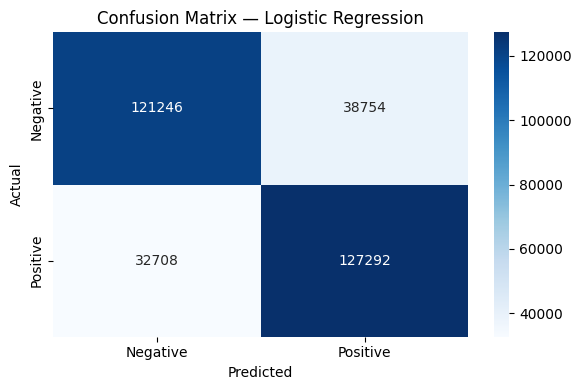

In [51]:
# ============================================================
# 📊 LOGISTIC REGRESSION — CLASSIFICATION REPORT + CONFUSION MATRIX
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

lr_train_pred = model.predict(X_train)
lr_test_pred  = model.predict(X_test)
lr_train_acc  = accuracy_score(Y_train, lr_train_pred)
lr_test_acc   = accuracy_score(Y_test,  lr_test_pred)

print("=" * 50)
print("   LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"  Train Accuracy : {lr_train_acc:.4f}")
print(f"  Test  Accuracy : {lr_test_acc:.4f}")
print(f"  Overfit Gap    : {lr_train_acc - lr_test_acc:.4f}")
print()
print(classification_report(Y_test, lr_test_pred, target_names=['Negative', 'Positive']))

cm_lr = confusion_matrix(Y_test, lr_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### 3️⃣ XGBoost — Detailed Metrics + Overfitting Analysis

   XGBOOST RESULTS
  Train Accuracy : 0.7434
  Test  Accuracy : 0.7388
  Overfit Gap    : 0.0047  ← Overfitting on sparse TF-IDF

              precision    recall  f1-score   support

    Negative       0.79      0.65      0.71    160000
    Positive       0.70      0.83      0.76    160000

    accuracy                           0.74    320000
   macro avg       0.75      0.74      0.74    320000
weighted avg       0.75      0.74      0.74    320000



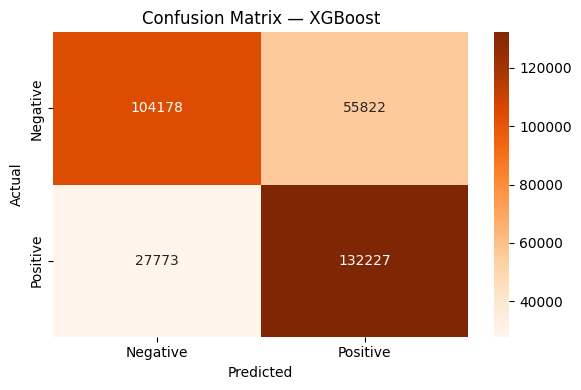

In [52]:
# ============================================================
# 📊 XGBOOST — CLASSIFICATION REPORT + OVERFITTING ANALYSIS
# ============================================================

print("=" * 50)
print("   XGBOOST RESULTS")
print("=" * 50)
print(f"  Train Accuracy : {xgb_train_acc:.4f}")
print(f"  Test  Accuracy : {xgb_test_acc:.4f}")
print(f"  Overfit Gap    : {xgb_train_acc - xgb_test_acc:.4f}  ← Overfitting on sparse TF-IDF")
print()
print(classification_report(Y_test, xgb_test_pred, target_names=['Negative', 'Positive']))

cm_xgb = confusion_matrix(Y_test, xgb_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### 4️⃣ Model Comparison — LR vs XGBoost

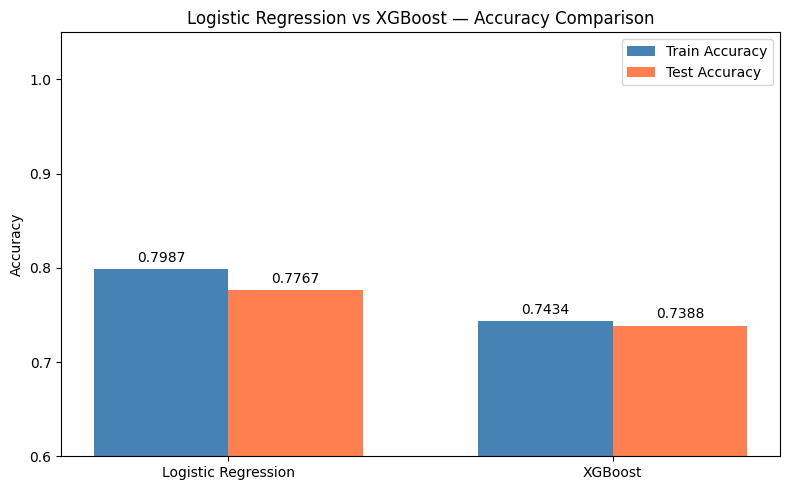


📌 Observation:
  LR  overfit gap : 0.0220 → Better generalization
  XGB overfit gap : 0.0047 → Overfits sparse TF-IDF features
  ✅ Logistic Regression outperforms XGBoost on high-dimensional text data


In [53]:
# ============================================================
# 📊 MODEL COMPARISON — LR vs XGBoost (Bar Chart)
# ============================================================
import numpy as np

models     = ['Logistic Regression', 'XGBoost']
train_accs = [lr_train_acc, xgb_train_acc]
test_accs  = [lr_test_acc,  xgb_test_acc]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, train_accs, width, label='Train Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, test_accs,  width, label='Test Accuracy',  color='coral')

ax.set_ylabel('Accuracy')
ax.set_title('Logistic Regression vs XGBoost — Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.60, 1.05)
ax.legend()
ax.bar_label(bars1, fmt='%.4f', padding=3)
ax.bar_label(bars2, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

print("\n📌 Observation:")
print(f"  LR  overfit gap : {lr_train_acc  - lr_test_acc :.4f} → Better generalization")
print(f"  XGB overfit gap : {xgb_train_acc - xgb_test_acc:.4f} → Overfits sparse TF-IDF features")
print("  ✅ Logistic Regression outperforms XGBoost on high-dimensional text data")

### 5️⃣ Save Models + Vectorizer using Pickle

In [54]:
# ============================================================
# 💾 SAVE MODELS + VECTORIZER USING PICKLE
# ============================================================
import pickle
import os

os.makedirs("saved_models", exist_ok=True)

# Save Logistic Regression
with open("saved_models/logistic_regression_model.pkl", "wb") as f:
    pickle.dump(model, f)
print("✅ Logistic Regression model saved.")

# Save XGBoost
with open("saved_models/xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb, f)
print("✅ XGBoost model saved.")

# ⚠️ MUST save vectorizer — without this deployment fails
with open("saved_models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)
print("✅ TF-IDF Vectorizer saved.")

print("\n📁 Saved files:")
for fname in os.listdir("saved_models"):
    size = os.path.getsize(f"saved_models/{fname}")
    print(f"   {fname}  —  {size/1024:.1f} KB")

✅ Logistic Regression model saved.
✅ XGBoost model saved.
✅ TF-IDF Vectorizer saved.

📁 Saved files:
   xgboost_model.pkl  —  1004.1 KB
   tfidf_vectorizer.pkl  —  10845.0 KB
   logistic_regression_model.pkl  —  3606.1 KB


### 6️⃣ Deployment — Load Model & Predict on New Raw Tweets

In [55]:
# ============================================================
# 🚀 DEPLOYMENT — LOAD MODEL & PREDICT ON NEW RAW TWEETS
# ============================================================
import pickle
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
import re

# Load saved model and vectorizer from disk
with open("saved_models/logistic_regression_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

with open("saved_models/tfidf_vectorizer.pkl", "rb") as f:
    loaded_vectorizer = pickle.load(f)

# Same preprocessing function used during training
port_stem = PorterStemmer()

def preprocess(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower().split()
    text = [port_stem.stem(w) for w in text if w not in stopwords.words('english')]
    return ' '.join(text)

# New raw tweets to test deployment
sample_tweets = [
    "I absolutely love this! Best thing ever, feeling amazing today.",
    "This is terrible, nothing is working. Worst experience of my life.",
    "Just had coffee and reading a book, peaceful morning!",
    "Stuck in traffic again, late for work and so frustrated.",
    "Happy birthday to my best friend, hope you have a wonderful day!"
]

print("=" * 60)
print("     🚀 DEPLOYMENT INFERENCE — NEW TWEET PREDICTIONS")
print("=" * 60)

for tweet in sample_tweets:
    cleaned    = preprocess(tweet)
    vectorized = loaded_vectorizer.transform([cleaned])
    pred       = loaded_model.predict(vectorized)[0]
    confidence = loaded_model.predict_proba(vectorized)[0][pred]
    label      = "😊 Positive" if pred == 1 else "😞 Negative"

    print(f"\nTweet      : {tweet}")
    print(f"Sentiment  : {label}  (Confidence: {confidence:.2%})")

print("\n" + "=" * 60)
print("✅ Model loaded from Pickle and deployed successfully!")

     🚀 DEPLOYMENT INFERENCE — NEW TWEET PREDICTIONS

Tweet      : I absolutely love this! Best thing ever, feeling amazing today.
Sentiment  : 😊 Positive  (Confidence: 95.60%)

Tweet      : This is terrible, nothing is working. Worst experience of my life.
Sentiment  : 😞 Negative  (Confidence: 98.66%)

Tweet      : Just had coffee and reading a book, peaceful morning!
Sentiment  : 😊 Positive  (Confidence: 92.86%)

Tweet      : Stuck in traffic again, late for work and so frustrated.
Sentiment  : 😞 Negative  (Confidence: 99.84%)

Tweet      : Happy birthday to my best friend, hope you have a wonderful day!
Sentiment  : 😊 Positive  (Confidence: 98.26%)

✅ Model loaded from Pickle and deployed successfully!
